In [1]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
from utils import tabulate_neatly
import SPDE
import yaml
import time

# Flags

Runs experiment for those which are set to true

In [2]:
HEAT = True
NAGUMO = True
ALLEN_CAHN = True
KDV = True
BURGERS = False

DRIFT = True
DIFFUSION = True

LIMIT_DERIVATIVES = False
LIMIT_POLYNOMIALS = False

RANDOM_INITIAL_CONDITIONS = True
GENERATE_PREDICTION_DATA = True
GENERATE_TRAINING_DATA = True
RUN_LASSO = False
RUN_SINDY = True

LEGENDRE_POLYNOMIALS = False
# DO_FANCY_VB = False
# if DO_FANCY_VB:
#     LIMIT_DERIVATIVES = True # safety
#     LIMIT_POLYNOMIALS = True

ALGORITHMS = {"Lasso": RUN_LASSO, "SINDy": RUN_SINDY}
IDENTIFICATION_TASKS = {"Drift": DRIFT, "Diffusion": DIFFUSION}

#### Generate Data

In [3]:
import DataGenerator as dg

experimentKeys = {"Heat": HEAT,
 "Nagumo": NAGUMO,
 "Allen_Cahn": ALLEN_CAHN,
 "KdV": KDV,
 "Burgers": BURGERS
 }

for key, value in experimentKeys.items():
    if value and GENERATE_TRAINING_DATA:
        dg.generateData(key, randomConditions=RANDOM_INITIAL_CONDITIONS)

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython
Sample number:  0
Sample number:  100
Sample number:  200
Sample number:  300
Sample number:  400
Sample number:  500
Sample number:  600
Sample number:  700
Sample number:  800
Sample number:  900
Sample number:  1000
Sample number:  1100
Sample number:  1200
Sample number:  1300
Sample number:  1400
Sample number:  1500
Sample number:  1600
Sample number:  1700
Sample number:  1800
Sample number:  1900
uStorage shape: (64, 501, 2000)
xdt shape: (64, 500)
xdiff shape: (64, 500)
Sample number:  0
Sample number:  100
Sample number:  200
Sample number:  300
Sample number:  400
Sample number:  500
Sample number:  600
Sample number:  700
Sample number:  800
Sample number:  900
Sample number:  1000
Sample number:  1100
Sample number:  1200
Sample number:  1300
Sample number:  1400
Sample number:  1500
Sample number:  1600
Sample number:  1700
Sample number:  1800
Sample number: 

#### Mean of Dictionaries

In [4]:


with open("parameters.yaml") as f:
    yamlParameters = yaml.safe_load(f)

space = yamlParameters["common"]["x_end"] - yamlParameters["common"]["x_start"]
timeRange = yamlParameters["common"]["t_end"] - yamlParameters["common"]["t_start"]
timeSteps = yamlParameters["common"]["timesteps"]
spacePoints = yamlParameters["common"]["J"]
isPeriodic = yamlParameters["common"]["periodic"]

problemDictionaries = {}
problemDescriptions = {}

for key, value in experimentKeys.items():
    if value:   
        U = np.load(f'data/{key}_dx_{spacePoints}m_{timeSteps}t.npy')
        dx = space/(U.shape[0])
        dt = timeRange/(U.shape[1]-1)
        
        Dictt = []
        for i in range(U.shape[2]):
            if i%100==0:
                print(i)
            U_t,Di,description = SPDE.build_linear_system(U[:,:-1,i], dt, dx, D = 3 if LIMIT_DERIVATIVES else 6, P = 3 if LIMIT_POLYNOMIALS else 6, periodic=isPeriodic, legendre=LEGENDRE_POLYNOMIALS)
            Dictt.append(Di)
        Dictt = np.mean(np.array(Dictt), axis=0)
        problemDictionaries[key] = Dictt
        problemDescriptions[key] = description

0
100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
0
100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
0
100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
0
100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900


In [5]:
indices = [451, 745]

SHOW_U_DISTRIBUTION = False

if SHOW_U_DISTRIBUTION:
    for index in indices:
        colors = {'Heat': 'steelblue', 'Nagumo': 'darkorange', 'Allen_Cahn': 'green', 'KdV': 'purple'}
        fig, axes = plt.subplots(1, len([k for k, v in experimentKeys.items() if v]), figsize=(5 * sum(experimentKeys.values()), 4))
        axes = np.atleast_1d(axes)
        for ax, key in zip(axes, [k for k, v in experimentKeys.items() if v]):
            U = np.load(f'data/{key}_dx_{spacePoints}m_{timeSteps}t.npy')
            
            normalised_vals = []
            # for s in range(U.shape[2]):
            u_traj = U[:, :-1, index]
            umin, umax = u_traj.min(), u_traj.max()
            if not np.isclose(umin, umax):
                u_scaled = 2 * (u_traj - umin) / (umax - umin) - 1
                normalised_vals.append(u_scaled.flatten())

            normalised_vals = np.concatenate(normalised_vals)
            ax.hist(normalised_vals, bins=100, color=colors[key], alpha=0.8, density=True)
            ax.set_title(key.replace('_', ' '), fontweight='bold')
            ax.set_xlabel('Normalised u value')
            ax.set_ylabel('Density')
            ax.set_xlim(-1, 1)
            ax.grid(color='gray', linestyle='--', linewidth=0.5)

        plt.suptitle('Distribution of per-trajectory $\\tilde{u}$ values. Index: ' + str(index), fontweight='bold')
        plt.tight_layout()
        plt.savefig(f'worthwhileImages/u_value_histograms_index_{index}.pdf', dpi=150, bbox_inches='tight')
        plt.show()

# Lasso and SINDy

In [6]:
#mildly accurate

if not LEGENDRE_POLYNOMIALS:
    TRUE_PDE_DRIFT = {
        "Heat":       {"u_xx": "epsilon"},
        "Allen_Cahn": {"u_xx": "epsilon", "u": "u_coeff", "u^3": "u3_coeff"},
        "Nagumo":     {"u_xx": "epsilon", "u": "u_coeff", "u^2": "u2_coeff", "u^3": "u3_coeff"},
        "KdV":        {"uu_x": "uu_x_coeff", "u_xxx": "u_xxx_coeff"},
        "Burgers":    {"uu_x": "uu_x_coeff", "u_xx": "epsilon"},
    }
    TRUE_PDE_DIFFUSION = {
        "Heat":       {"1": "sigma"},
        "Allen_Cahn": {"1": "sigma"},
        "Nagumo":     {"1": "sigma"},
        "KdV":        {"1": "sigma"},
        "Burgers":    {"1": "sigma", "u": "u_coeff", "u^2": "u2_coeff"},
    }
else:
    # NOTE: definitely inaccurate wrt expansions but just needed something to make the rest run 
    TRUE_PDE_DRIFT = {
        "Heat":       {"P0(u)u_xx": "epsilon"},
        "Allen_Cahn": {"P0(u)u_xx": "epsilon", "P1(u)": "u_coeff", "P3(u)": "u3_coeff"},
        "Nagumo":     {"P0(u)u_xx": "epsilon", "P1(u)": "u_coeff", "P2(u)": "u2_coeff", "P3(u)": "u3_coeff"},
        "KdV":        {"P1(u)u_x": "uu_x_coeff", "P0(u)u_xxx": "u_xxx_coeff"},
        "Burgers":    {"P1(u)u_x": "uu_x_coeff", "P0(u)u_xx": "epsilon"},
    }
    TRUE_PDE_DIFFUSION = {
        "Heat":       {"P0(u)": "sigma"},
        "Allen_Cahn": {"P0(u)": "sigma"},
        "Nagumo":     {"P0(u)": "sigma"},
        "KdV":        {"P0(u)": "sigma"},
        "Burgers":    {"P0(u)": "sigma"},
    }

def buildTrueCoeffs(problem, description, yaml_params, term_map, drift=True):
    if term_map is None:
        print(f"Warning: true coefficients for {problem} undefined in Legendre basis")
        return None
    coeffs = np.zeros(len(description))
    params = yaml_params[problem.lower()]["correct"]["drift" if drift else "diffusion"]
    for label, yaml_key in term_map.items():
        if label not in description:
            print(f"Warning: '{label}' not in dictionary for {problem}. Increase D or P")
            continue
        coeffs[description.index(label)] = params[yaml_key]
    return coeffs

Xi_drift_true = {
    p: buildTrueCoeffs(p, problemDescriptions[p], yamlParameters, TRUE_PDE_DRIFT[p], drift=True)
    for p in problemDictionaries
}
Xi_diffusion_true = {
    p: buildTrueCoeffs(p, problemDescriptions[p], yamlParameters, TRUE_PDE_DIFFUSION[p], drift=False)
    for p in problemDictionaries
}

In [7]:
results = []

for identificationTask, value in IDENTIFICATION_TASKS.items():
    if value:
        for algorithm, value in ALGORITHMS.items():
            if value:
                for problem, dictionary in problemDictionaries.items():
                    if identificationTask == "Drift":
                        target = np.load(f'data/{problem}_xdt_{spacePoints}m_{timeSteps}t.npy')
                    elif identificationTask == "Diffusion":
                        target = np.load(f'data/{problem}_xdiff_{spacePoints}m_{timeSteps}t.npy')
                    np.random.seed(0)
                    
                    target = target.reshape(1,-1, order='F')
                    start_time = time.time()
                    lam = yamlParameters["common"][f"{algorithm.lower()}_{identificationTask.lower()}_lambda"]
                    if algorithm == "Lasso":
                        Xi_coeffs = SPDE.Lasso(dictionary, target, lam)
                    elif algorithm == "SINDy":
                        Xi_coeffs = SPDE.sindy(lam, dictionary, target)
                    end_time = time.time()

                    targetCoeffs = Xi_drift_true[problem] if identificationTask == "Drift" else Xi_diffusion_true[problem]

                    # print discovered terms for SINDy only (Lasso expected to be less sparse)
                    if algorithm == "SINDy":
                        description = problemDescriptions[problem]
                        discovered = [
                            (description[i] if description[i] != '' else '1', round(float(Xi_coeffs.reshape(-1)[i]), 4))
                            for i in range(len(Xi_coeffs.reshape(-1)))
                            if Xi_coeffs.reshape(-1)[i] != 0
                        ]
                        print(f"\nSINDy discovered terms ({problem} | {identificationTask}):")
                        for term, coeff in discovered:
                            print(f"  {term}: {coeff}")

                    l2_error = np.linalg.norm(targetCoeffs - Xi_coeffs.reshape(-1))

                    corr_ind = []
                    for i in range(len(targetCoeffs)):
                        if targetCoeffs[i] != 0:
                            corr_ind.append(i)

                    fp = 0
                    for i in range(len(targetCoeffs)):
                        if i in corr_ind:
                            pass
                        else:
                            if Xi_coeffs.reshape(-1)[i] != 0:
                                fp += 1

                    total_negatives = len(targetCoeffs) - len(corr_ind)
                    fpr = (fp / total_negatives) * 100  # expect legendre to mess up here in terms of coeffs, due to scaling + nonstandard polynomial

                    results.append([f"{problem} | {identificationTask}", algorithm, round(l2_error, 4), round(fpr, 2), round(end_time - start_time, 4)])

tabulate_neatly(results, headers=["Problem", "Algorithm", "L2 Error", "FPR (%)", "Time (s)"], title="Identification Results")


SINDy discovered terms (Heat | Drift):
  u_xx: 1.0091

SINDy discovered terms (Nagumo | Drift):
  u: 0.4238
  u^3: -0.7592
  u^4: 2.851
  u^6: -2.7057
  u^2u_x: 0.4584
  u^4u_x: -5.9612
  u^5u_x: -1.1407
  u^6u_x: 8.1939
  u_xx: 0.9663
  u^4u_xxx: -0.4166
  u^6u_xxx: 0.6414

SINDy discovered terms (Allen_Cahn | Drift):
  u: 1.2741
  u^3: -2.0696
  u^4: 0.3748
  u^5: 0.9933
  u^6: -0.5023
  u^2u_x: 1.2795
  u^4u_x: -6.458
  u^6u_x: 4.483
  u_xx: 0.9734
  u^2u_xx: 0.3427
  u^4u_xx: -0.6308
  u^6u_xx: 0.3655

SINDy discovered terms (KdV | Drift):
  uu_x: -1.0413
  u_xxx: -0.9961

SINDy discovered terms (Heat | Diffusion):
  1: 0.9787

SINDy discovered terms (Nagumo | Diffusion):
  1: 0.9786

SINDy discovered terms (Allen_Cahn | Diffusion):
  1: 0.9792

SINDy discovered terms (KdV | Diffusion):
  1: 0.9828
  u: 0.106
  u^2: 0.3094
  uu_x: 0.1884
  uu_xx: -0.2592


Identification Results

Problem,Algorithm,L2 Error,FPR (%),Time (s)
Heat | Drift,SINDy,0.0091,0,0.223
Nagumo | Drift,SINDy,10.9789,17.78,0.314
Allen_Cahn | Drift,SINDy,8.1663,19.57,0.2771
KdV | Drift,SINDy,0.0415,0,0.1077
Heat | Diffusion,SINDy,0.0213,0,0.0919
Nagumo | Diffusion,SINDy,0.0214,0,0.0984
Allen_Cahn | Diffusion,SINDy,0.0208,0,0.1596
KdV | Diffusion,SINDy,0.4582,8.33,0.1517


# Variational Bayes

NOTE: Fixed, using one-initialisation

In [8]:
for fancyVBSwitch in [False, True]:
    DO_FANCY_VB = fancyVBSwitch
    results_vb = []
    problemDS = {}
    results_vb_variances = []
    for identificationTask, value in IDENTIFICATION_TASKS.items():
        if value:
            for problem, dictionary in problemDictionaries.items():

                if identificationTask == "Drift":
                    target = np.load(f'data/{problem}_xdt_{spacePoints}m_{timeSteps}t.npy')
                elif identificationTask == "Diffusion":
                    target = np.load(f'data/{problem}_xdiff_{spacePoints}m_{timeSteps}t.npy')

                y = target.reshape(-1, order='F')

                np.random.seed(30)
                initz0 = np.ones(dictionary.shape[1])

                tol = 0.000001
                verbosity = False                

                # -------------------------------------------------
                # VB inference
                # -------------------------------------------------
                start_time = time.time()
                DS = SPDE.Variational_Bayes_Code(
                    dictionary,
                    y,
                    initz0,
                    tol,
                    verbosity,
                    p0=0.1,
                    vs=100
                ) if not DO_FANCY_VB else SPDE.ormerodAlgorithm2(dictionary, y, tol, verbosity, p0=0.1, vs=100)

                problemDS.setdefault(problem, {})[identificationTask] = DS
                end_time = time.time()
                print(f"Time taken for VB inference on {problem} | {identificationTask}: {end_time-start_time:.4f} seconds.")

                # for i in range(dictionary.shape[1]):
                #     if abs(DS['wmean'][i]) <= 0.01:
                #         DS['zmean'][i] = 0
                #         DS['wmean'][i] = 0

                targetCoeffs = (
                    Xi_drift_true[problem]
                    if identificationTask == "Drift"
                    else Xi_diffusion_true[problem]
                )

                l2_error_vb = np.linalg.norm(targetCoeffs - DS['wmean'])

                corr_ind = []
                for i in range(len(targetCoeffs)):
                    if targetCoeffs[i] != 0:
                        corr_ind.append(i)

                fp_vb = 0
                for i in range(len(targetCoeffs)):
                    if i in corr_ind:
                        pass
                    else:
                        if DS['wmean'][i] != 0:
                            fp_vb += 1

                total_negatives = len(targetCoeffs) - len(corr_ind)
                fpr_vb = (fp_vb / total_negatives) * 100

                results_vb.append([
                    f"{problem} | {identificationTask}",
                    round(l2_error_vb, 4),
                    round(fpr_vb, 2),
                    round(end_time - start_time, 4)
                ])

                # -------------------------------------------------
                # variance table - only for discovered terms (PIP > 0.5)
                # -------------------------------------------------
                description = problemDescriptions[problem]
                variances = np.diag(DS['wCOV'])

                for i in range(len(DS['zmean'])):
                    if DS['zmean'][i] > 0.5:
                        label = description[i] if description[i] != '' else '1'
                        results_vb_variances.append([
                            f"{problem} | {identificationTask}",
                            label,
                            round(float(DS['wmean'][i]), 4),
                            round(float(variances[i]), 6)
                        ])

    # tabulate_neatly(
    #     results_vb,
    #     headers=["Problem", "L2 Error", "FPR (%)", "Time (s)"],
    #     title="Variational Bayes Drift Results"
    # )

    tabulate_neatly(
        results_vb_variances,
        headers=["Problem", "Term", "Mean", "Variance"],
        title="Variational Bayes Discovered Coefficients"
    )
    print("="*50)

Time taken for VB inference on Heat | Drift: 5.1068 seconds.
Time taken for VB inference on Nagumo | Drift: 6.6006 seconds.
Time taken for VB inference on Allen_Cahn | Drift: 6.5669 seconds.
Time taken for VB inference on KdV | Drift: 4.0955 seconds.
Time taken for VB inference on Heat | Diffusion: 7.0387 seconds.
Time taken for VB inference on Nagumo | Diffusion: 3.7418 seconds.
Time taken for VB inference on Allen_Cahn | Diffusion: 1.6211 seconds.
Time taken for VB inference on KdV | Diffusion: 3.6907 seconds.


Variational Bayes Discovered Coefficients

Problem,Term,Mean,Variance
Heat | Drift,1,-0.033,0.001074
Heat | Drift,u,-0.1269,0.022844
Heat | Drift,u^2,0.6537,0.176267
Heat | Drift,u^3,0.8283,0.534366
Heat | Drift,u^4,-1.5767,1.24044
Heat | Drift,u^5,-0.973,0.894247
Heat | Drift,u^6,0.9927,0.712081
Heat | Drift,uu_x,-0.1831,0.065239
Heat | Drift,u^3u_x,0.6185,1.61773
Heat | Drift,u^4u_x,1.0703,0.180904


[Phase 1] Step 1/49: added term 14, ELBO = -22447.5489 (prev = -inf)
[Phase 1] Step 2/49: added term 4, ELBO = -22447.5489 (prev = -22447.5489)
[Phase 1] Converged at step 2, no further improvement.
[Phase 1] Complete. Active terms: [4, 14], ELBO = -22447.5489

[Phase 2] Iteration 1/100: best rho = 0.0447, ELBO = -22446.3568
[Phase 2] Iteration 1/100: after term selection, active terms = [0, 4, 8, 10, 14, 23, 25, 26, 28, 30, 33, 37, 41]
[Phase 2] Iteration 1/100: ELBO after term selection = -22446.3568 (prev = -22447.5489)
[Phase 2] Iteration 2/100: best rho = 0.0447, ELBO = -22446.3568
[Phase 2] Iteration 2/100: after term selection, active terms = [0, 5, 7, 9, 14, 19, 20, 21, 22, 23, 24, 26, 27, 30, 37, 38, 40]
[Phase 2] Iteration 2/100: ELBO after term selection = -22446.3568 (prev = -22446.3568)
[Phase 2] Converged at iteration 2.
[Phase 2] Complete. Final active terms: [0, 5, 7, 9, 14, 19, 20, 21, 22, 23, 24, 26, 27, 30, 37, 38, 40], ELBO = -22446.3568
Time taken for VB inference 

Variational Bayes Discovered Coefficients

Problem,Term,Mean,Variance
Heat | Drift,1,-0.0008,7e-06
Heat | Drift,u_xx,1.0091,0.000199
Nagumo | Drift,1,-0.0135,6.3e-05
Nagumo | Drift,u,0.3482,0.000963
Nagumo | Drift,u^2,0.5906,0.00221
Nagumo | Drift,u^5,-1.0978,0.020105
Nagumo | Drift,u_xx,0.9774,0.000375
Allen_Cahn | Drift,1,-0.0005,9e-06
Allen_Cahn | Drift,u,1.017,0.001677
Allen_Cahn | Drift,u^3,-1.0516,0.008017


### Plots

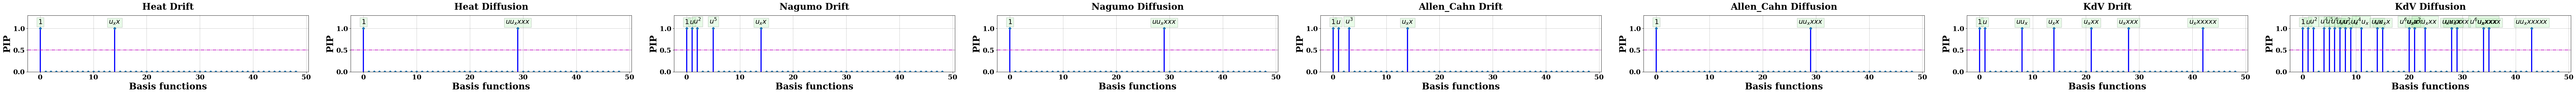

In [9]:
plt.rcParams["font.family"] = "serif"
plt.rcParams['font.size'] = 24

fig, axes = plt.subplots(1, len(problemDictionaries) * (2 if (DRIFT and DIFFUSION) else 1), figsize=(12 * len(problemDictionaries) * (2 if (DRIFT and DIFFUSION) else 1), 4))
axes = np.atleast_1d(axes)  # ensures axes is always an array even with 1 subplot

ax_idx = 0
for problem, experimentSet in problemDS.items():
    for identificationTask, DS in experimentSet.items():
        ax = axes[ax_idx]
        ax_idx += 1
        xr = np.array(range(len(DS['zmean'])))

        ax.vlines(xr, 0, DS['zmean'], colors='blue', linewidth=3.0)
        ax.plot(xr, DS['zmean'], 'C0D', markersize=5)
        ax.axhline(y=0.5, color='m', linestyle='-.')

        # annotate discovered terms with PIP > 0.5
        description = problemDescriptions[problem]
        for i, pip in enumerate(DS['zmean']):
            if pip > 0.5:
                label = f"${description[i]}$" if description[i] != '' else '$1$'
                ax.text(i, 1.1, label, bbox=dict(facecolor='lightgreen', alpha=0.2), fontsize=18, ha='center')

        ax.set_xlabel('Basis functions', fontweight='bold', fontsize=24)
        ax.set_ylabel('PIP', fontweight='bold', fontsize=24)
        ax.set_title(f'{problem} {identificationTask}', fontweight='bold', fontsize=24, pad=15)
        ax.grid(color='gray', linestyle='--', linewidth=0.5)
        ax.set_ylim(0, 1.3)
        ax.tick_params(axis='both', labelsize=18)
        for tick in ax.get_xticklabels() + ax.get_yticklabels():
            tick.set_fontweight('bold')

plt.tight_layout()
plt.show()

### Write Coeffs out to yaml

In [10]:
for problem, experimentSet in problemDS.items():
    for identificationTask, DS in experimentSet.items():
        if not yamlParameters[problem.lower()].get("discovered"):
            yamlParameters[problem.lower()]["discovered"] = {}
        disc = yamlParameters[problem.lower()]["discovered"]
        variances = np.diag(DS['wCOV'])
        
        # map description labels to discovered values and variances
        for i in range(len(DS['zmean'])):
            if DS['zmean'][i] > 0.5:
                description = problemDescriptions[problem]
                label = description[i] if description[i] != '' else '1'
                mean_val = round(float(DS['wmean'][i]), 6)
                var_val  = round(float(variances[i]), 8)
                
                #clean this up it looks terrible - maybe use a dictionary to map labels to yaml keys?
                #probably retrieve how this is done from SPDE.py and use the same mapping here to ensure consistency
                label_to_yaml = {
                    'u_xx': ('epsilon', 'epsilon_variance'),
                    '1': ('sigma_squared', 'sigma_squared_variance'),
                    'u': ('u_coeff', 'u_coeff_variance'),
                    'u^2': ('u2_coeff', 'u2_coeff_variance'),
                    'u^3': ('u3_coeff', 'u3_coeff_variance'), 
                    'uu_x': ('uu_x_coeff', 'uu_x_coeff_variance'),
                    'u_xxx': ('u_xxx_coeff', 'u_xxx_coeff_variance')
                }
                
                if label in label_to_yaml:
                    yaml_key, yaml_variance_key = label_to_yaml[label]
                    disc.setdefault(identificationTask.lower(), {})[yaml_key] = mean_val
                    disc[identificationTask.lower()][yaml_variance_key] = var_val
        yamlParameters[problem.lower()]["discovered"] = disc

UPDATE_PARAMETERS = False
if UPDATE_PARAMETERS:
    with open("parameters.yaml", "w") as f:
        yaml.dump(yamlParameters, f, default_flow_style=False, sort_keys=False)

### Collinearity Analysis

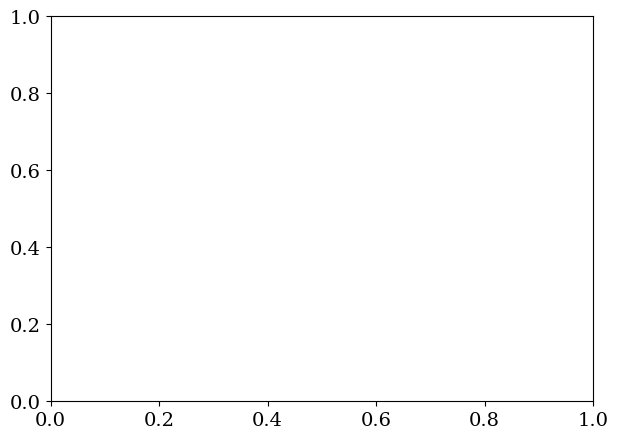

In [11]:
import matplotlib.pyplot as plt
import yaml
import numpy as np

plt.rcParams["font.family"] = "serif"
plt.rcParams['font.size'] = 14
colors = {'Heat': 'steelblue', 'Nagumo': 'darkorange', 'Allen_Cahn': 'green', 'KdV': 'purple'}

fig, ax = plt.subplots(1, 1, figsize=(7, 5))

DO_SMOOTHNESS_ANALYSIS = False

with open("parameters.yaml") as f:
    yamlParameters = yaml.safe_load(f)
space = yamlParameters["common"]["x_end"] - yamlParameters["common"]["x_start"]
timeRange = yamlParameters["common"]["t_end"] - yamlParameters["common"]["t_start"]
timeSteps = yamlParameters["common"]["timesteps"]
spacePoints = yamlParameters["common"]["J"]
isPeriodic = yamlParameters["common"]["periodic"]

if DO_SMOOTHNESS_ANALYSIS:
    for problem in experimentKeys:
        if not experimentKeys[problem]:
            continue
        
        U = np.load(f'data/{problem}_dx_{spacePoints}m_{timeSteps}t.npy')
        # U shape: (space, time, samples)
        dx = space / U.shape[0]
        
        # --- spatial power spectrum ---
        # compute FFT along spatial axis for each timestep and sample
        # average power across time and samples to get mean spectrum
        fft_vals = np.fft.rfft(U, axis=0)  # FFT along space axis
        power = np.mean(np.abs(fft_vals)**2, axis=(1, 2))  # average over time and samples
        freqs = np.fft.rfftfreq(U.shape[0], d=dx)
        
        ax.semilogy(freqs[1:], power[1:],  # skip DC component (k=0)
                    color=colors[problem], linewidth=2,
                    label=problem.replace('_', ' '))

    ax.set_xlabel('Spatial frequency (1/L)', fontweight='bold')
    ax.set_ylabel('Power', fontweight='bold')
    ax.set_title('Spatial power spectrum of solution', fontweight='bold')
    ax.legend()
    ax.grid(color='gray', linestyle='--', linewidth=0.5)

    plt.tight_layout()
    plt.savefig('worthwhileImages/fourier_smoothness.pdf', dpi=150, bbox_inches='tight')
    plt.show()

In [12]:
    # per-trajectory correlation: u_xx vs u_xxxx
    # for each trajectory separately, compute correlation across space and time
DO_UXX_UXXXX_CORR = False # for now

if DO_UXX_UXXXX_CORR:
    for key, value in experimentKeys.items():
        if not value:
            continue
        U = np.load(f'data/{key}_dx_{spacePoints}m_{timeSteps}t.npy')
        N = U.shape[0]
        dx = space / U.shape[0]
        per_traj_corrs = []

        for sample in range(U.shape[2]):
            u_traj = U[:, :-1, sample]  # shape (64, 500)
            
            u_xx_traj = np.zeros_like(u_traj)
            u_xxxx_traj = np.zeros_like(u_traj)
            
            for t in range(u_traj.shape[1]):
                u_xx_traj[:, t] = SPDE.FiniteDiff(u_traj[:, t], dx, 2, periodic=True)
                u_xxxx_traj[:, t] = SPDE.FiniteDiff(u_traj[:, t], dx, 4, periodic=True) # just checking, but will probably have to regenerate data with more accurate stencils
            
            corr = np.corrcoef(u_xx_traj.flatten(), u_xxxx_traj.flatten())[0,1]
            per_traj_corrs.append(corr)

        per_traj_corrs = np.array(per_traj_corrs)

        print(f"Per-trajectory correlation u_xx vs u_xxxx:")
        print(f"  Mean: {np.mean(per_traj_corrs):.4f}")
        print(f"  Std:  {np.std(per_traj_corrs):.4f}")
        print(f"  Min:  {np.min(per_traj_corrs):.4f}")
        print(f"  Max:  {np.max(per_traj_corrs):.4f}")

        plt.figure(figsize=(8, 4))
        plt.hist(per_traj_corrs, bins=50)
        plt.xlabel('Per-trajectory correlation (u_xx vs u_xxxx)')
        plt.ylabel('Count')
        plt.title(f'Distribution of per-trajectory correlations - {key}')
        plt.axvline(np.mean(per_traj_corrs), color='red', linestyle='--', label=f'Mean={np.mean(per_traj_corrs):.3f}')
        plt.legend()
        plt.tight_layout()
        plt.savefig(f'worthwhileImages/per_traj_corr_{key.lower()}.pdf', dpi=150, bbox_inches='tight')
        plt.show()

In [13]:
import seaborn as sns

DO_HEATMAPS = False

plt.rcParams["font.family"] = "serif"
plt.rcParams['font.size'] = 10

if DO_HEATMAPS:
    for problem in experimentKeys:
        if not experimentKeys[problem]:
            continue

        desc = problemDescriptions[problem]
        dictionary = problemDictionaries[problem]
        corr = np.corrcoef(dictionary.T)

        labels = [d if d != '' else '1' for d in desc]

        fig, ax = plt.subplots(figsize=(max(8, 0.3 * len(desc)), max(8, 0.3 * len(desc))))
        sns.heatmap(
            corr,
            ax=ax,
            cmap='RdBu_r',
            vmin=-1, vmax=1,
            xticklabels=labels,
            yticklabels=labels,
            square=True,
            cbar_kws={'label': 'Pearson correlation'},
        )

        ax.set_title(f'Dictionary correlation matrix - {problem}', fontweight='bold')
        ax.tick_params(axis='x', labelrotation=90, labelsize=8)
        ax.tick_params(axis='y', labelrotation=0, labelsize=8)

        plt.tight_layout()
        plt.savefig(f'worthwhileImages/corr_heatmap_{problem.lower()}.pdf', dpi=150, bbox_inches='tight')
        plt.show()

In [14]:
DO_TEMPORAL_CORR_DIAGNOSTIC = False

if DO_TEMPORAL_CORR_DIAGNOSTIC:
    for key, value in experimentKeys.items():
        if not value:
            continue

        u = np.load(f'data/{key}_dx_{spacePoints}m_{timeSteps}t.npy')  # (N, T, samples)
        n = u.shape[0]
        dx = space / n

        uFull = u[:, :-1, :]                      # (N, T, samples)
        uMeanTraj = uFull.mean(axis=2)            # ensemble mean field, (N, T)
        tSteps = uFull.shape[1]

        def derivPerTimestep(traj, derivativeOrder):
            out = np.zeros_like(traj)
            for t in range(traj.shape[1]):
                out[:, t] = SPDE.FiniteDiff(
                    traj[:, t],
                    dx,
                    derivativeOrder,
                    periodic=True
                )
            return out

        # --- Check #1: per-timestep spatial-only correlation rho(t) ---
        nSampleTrajs = uFull.shape[2]
        rhoTraj = np.zeros((nSampleTrajs, tSteps))

        for sampleIdx in range(nSampleTrajs):
            uxxSample = derivPerTimestep(uFull[:, :, sampleIdx], 2)
            uxxxxSample = derivPerTimestep(uFull[:, :, sampleIdx], 4)

            for t in range(tSteps):
                rhoTraj[sampleIdx, t] = np.corrcoef(
                    uxxSample[:, t],
                    uxxxxSample[:, t]
                )[0, 1]

        uxxMean = derivPerTimestep(uMeanTraj, 2)
        uxxxxMean = derivPerTimestep(uMeanTraj, 4)

        rhoMean = np.array([
            np.corrcoef(uxxMean[:, t], uxxxxMean[:, t])[0, 1]
            for t in range(tSteps)
        ])

        plt.figure(figsize=(9, 4))

        for sampleIdx in range(nSampleTrajs):
            plt.plot(
                rhoTraj[sampleIdx],
                color='steelblue',
                alpha=0.25
            )  # see 3rd line - but not meaned (for every sample)

        plt.plot(
            rhoMean,
            color='red',
            linewidth=2,
            label='ensemble-mean solution'
        )  # average solutions over all samples, then correlations of these

        plt.plot(
            rhoTraj.mean(axis=0),
            color='black',
            linewidth=2,
            linestyle='--',
            label='mean of per-solution $\\rho(t)$'
        )  # correlations of each solution per time, then mean of these

        plt.xlabel('Timestep')
        plt.ylabel(r'$\rho(t)$: spatial corr($u_{xx}$, $u_{xxxx}$) at fixed $t$')
        plt.title(f'{key}: per-timestep correlation, solutions vs. mean solution')
        plt.legend()
        plt.grid(color='gray', linestyle='--', linewidth=0.5)
        plt.tight_layout()
        plt.savefig(
            f'worthwhileImages/rho_t_{key.lower()}.pdf',
            dpi=150,
            bbox_inches='tight'
        )
        plt.show()

        # --- Check #2: demeaned (fluctuation-only) correlation ---
        fluctCorrs = []

        for sampleIdx in range(nSampleTrajs):
            fluct = uFull[:, :, sampleIdx] - uMeanTraj  # this solution's noise component

            uxxFluct = derivPerTimestep(fluct, 2)
            uxxxxFluct = derivPerTimestep(fluct, 4)

            fluctCorrs.append(
                np.corrcoef(
                    uxxFluct.flatten(),
                    uxxxxFluct.flatten()
                )[0, 1]
            )

        fluctCorrs = np.array(fluctCorrs)

        print(f"\n=== {key} ===")
        print(
            f"Mean-solution correlation (flattened space-time): "
            f"{np.corrcoef(uxxMean.flatten(), uxxxxMean.flatten())[0, 1]:.4f}"
        )
        print(
            f"Per-solution full-field correlation: "
            f"mean={rhoTraj.mean():.4f}"
        )
        print(
            f"Per-solution FLUCTUATION-ONLY correlation: "
            f"mean={fluctCorrs.mean():.4f}, std={fluctCorrs.std():.4f}"
        )

# Prediction

Generate data per discovered coefficients

correct sample: 0
correct sample: 50
correct sample: 100
correct sample: 150
correct shape: (64, 501, 200)
pred sample: 0
pred sample: 50
pred sample: 100
pred sample: 150
pred shape: (64, 501, 200)


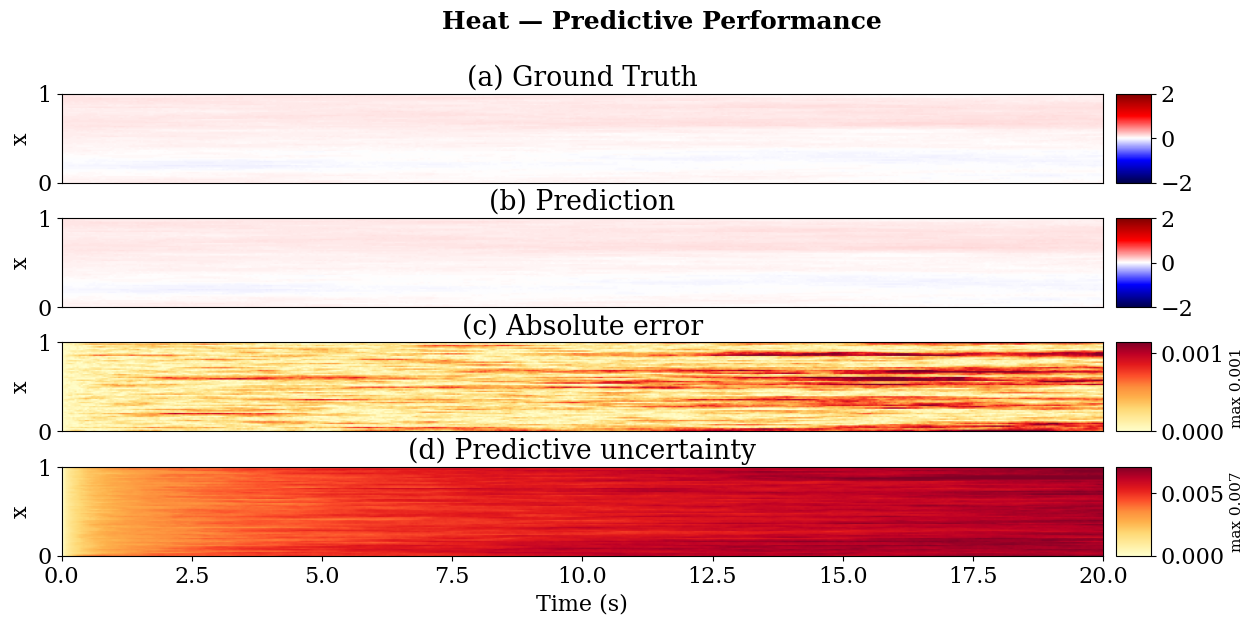

correct sample: 0
correct sample: 50
correct sample: 100
correct sample: 150
correct shape: (64, 501, 200)
pred sample: 0
pred sample: 50
pred sample: 100
pred sample: 150
pred shape: (64, 501, 200)


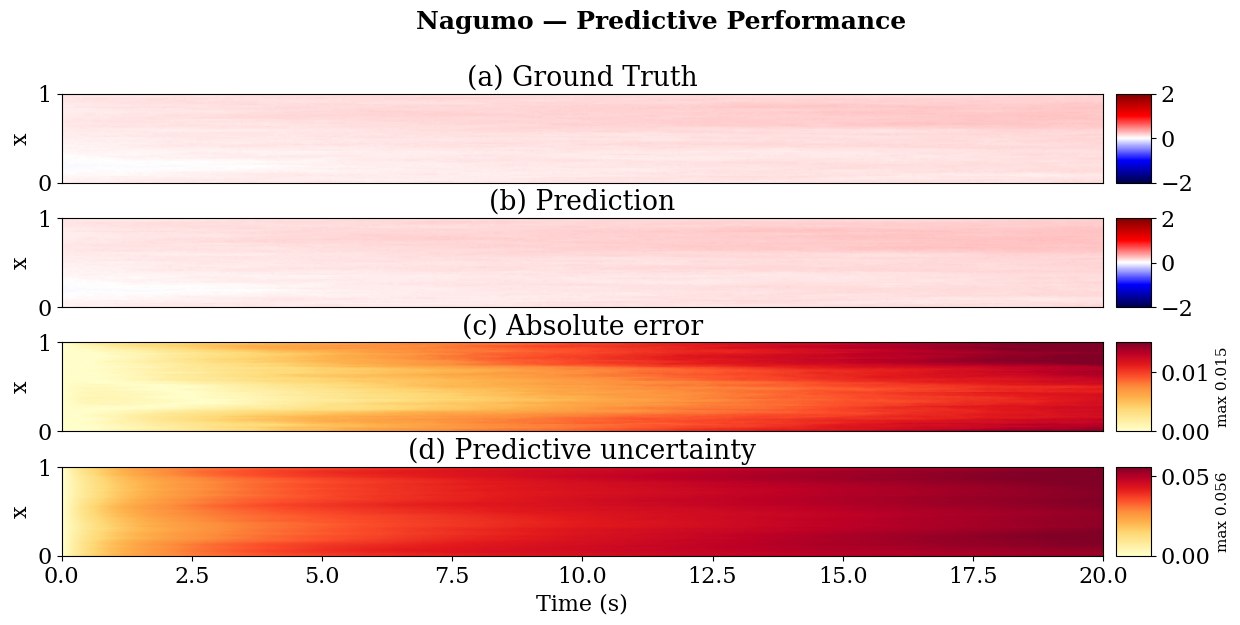

correct sample: 0
correct sample: 50
correct sample: 100
correct sample: 150
correct shape: (64, 501, 200)
pred sample: 0
pred sample: 50
pred sample: 100
pred sample: 150
pred shape: (64, 501, 200)


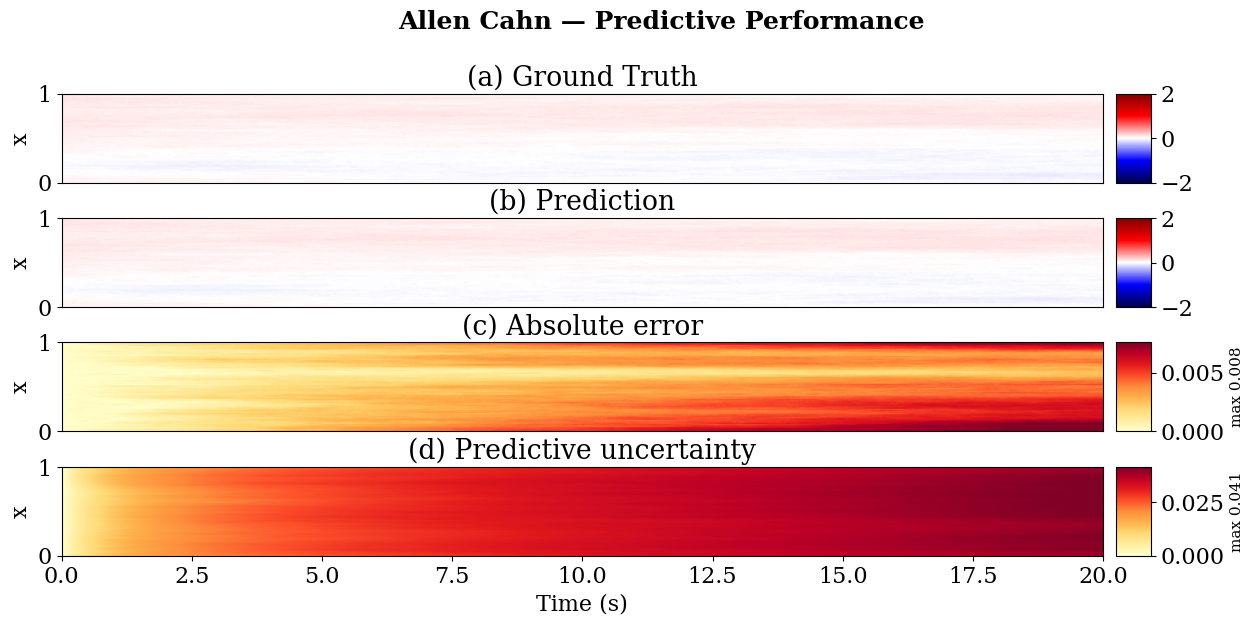

correct sample: 0
correct sample: 50
correct sample: 100
correct sample: 150
correct shape: (64, 501, 200)
pred sample: 0
pred sample: 50
pred sample: 100
pred sample: 150
pred shape: (64, 501, 200)


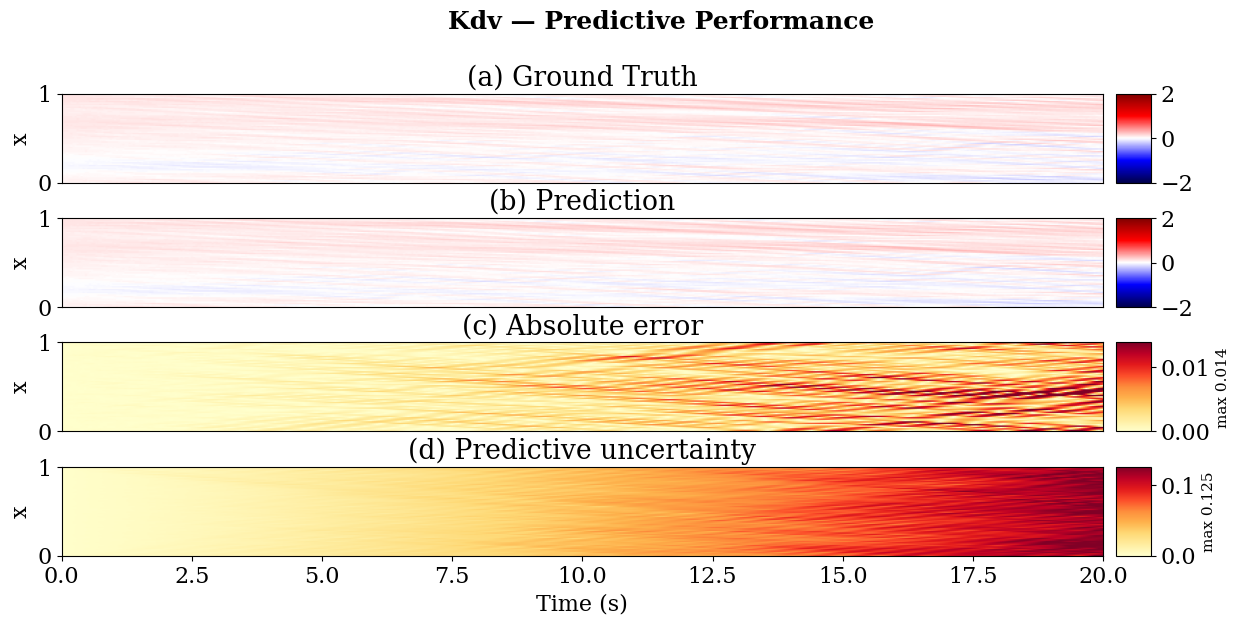

In [15]:
import PredictionDataGenerator

with open("parameters.yaml") as f:
    yamlParameters = yaml.safe_load(f)
for key, value in experimentKeys.items():
    if value:
        if GENERATE_PREDICTION_DATA:
            PredictionDataGenerator.generatePrediction(key)
        
        U3 = np.load(f'data/{key}_prediction_correct.npy')
        U4 = np.load(f'data/{key}_prediction_pred.npy')
        plt.rcParams['font.size'] = 16

        uu  = np.mean(U3, axis=2)
        uu1 = np.mean(U4, axis=2)
        err = np.abs(uu - uu1)
        unc = np.std(U3 - U4, axis=2)

        # per-problem scales — 99th percentile avoids outlier blow-up
        err_vmax = np.percentile(err, 99)
        unc_vmax = np.percentile(unc, 99)

        fig = plt.figure(figsize=(16, 6))
        fig.subplots_adjust(wspace=1, hspace=0.4)
        solution_cmap = 'seismic'
        error_cmap    = 'YlOrRd'

        plt.subplot(4, 1, 1)
        plt.imshow(uu, cmap=solution_cmap, aspect='auto', origin='lower',
                   extent=[0, 20, 0, 1], vmin=-2, vmax=2)
        plt.ylabel('x'); plt.title('(a) Ground Truth'); plt.xticks([], [])
        plt.colorbar(aspect=2.5, pad=0.01)

        plt.subplot(4, 1, 2)
        plt.imshow(uu1, cmap=solution_cmap, aspect='auto', origin='lower',
                   extent=[0, 20, 0, 1], vmin=-2, vmax=2)
        plt.ylabel('x'); plt.title('(b) Prediction'); plt.xticks([], [])
        plt.colorbar(aspect=2.5, pad=0.01)

        plt.subplot(4, 1, 3)
        plt.imshow(err, cmap=error_cmap, aspect='auto', origin='lower',
                   extent=[0, 20, 0, 1], vmin=0, vmax=err_vmax)
        plt.ylabel('x'); plt.title('(c) Absolute error'); plt.xticks([], [])
        cb = plt.colorbar(aspect=2.5, pad=0.01)
        cb.set_label(f'max {err_vmax:.3f}', fontsize=11)

        plt.subplot(4, 1, 4)
        plt.imshow(unc, cmap=error_cmap, aspect='auto', origin='lower',
                   extent=[0, 20, 0, 1], vmin=0, vmax=unc_vmax)
        plt.xlabel('Time (s)'); plt.ylabel('x')
        plt.title('(d) Predictive uncertainty')
        cb = plt.colorbar(aspect=2.5, pad=0.01)
        cb.set_label(f'max {unc_vmax:.3f}', fontsize=11)

        fig.suptitle(f'{key.replace("_", " ").title()} — Predictive Performance',
                     fontweight='bold', fontsize=18, y=1.02)
        plt.show()
        fig.savefig(f'worthwhileImages/{key}_prediction.pdf', format='pdf',
                    dpi=300, bbox_inches='tight')